# Wizualizacja danych w Pythonie
## Matplotlib & Seaborn — od podstaw

**Dane:** Pingwiny Palmer  
**Biblioteki:** `matplotlib`, `seaborn`, `pandas`, `numpy`


---
## 0. Import bibliotek

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Matplotlib od podstaw


Matplotlib rysuje na dwóch obiektach:
- **Figure** — cała "kartka papieru"
- **Axes** — jeden wykres (osie, dane, tytuł)

Minimalna recepta:
```python
plt.figure()          # nowa kartka
plt.plot(x, y)        # narysuj dane
plt.show()            # wyświetl
```

### 1.1 Jak narysować prostą

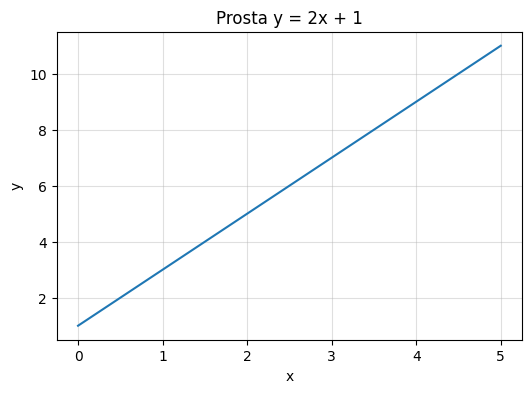

In [ ]:
# Prosta y = 2x + 1
x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))        # rozmiar figury w calach (szerokość, wysokość)
plt.plot(x, y)                    # rysuje linię łączącą punkty po kolei
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prosta y = 2x + 1')
plt.grid(True, alpha=0.4)         # siatka pomocnicza, alpha = przezroczystość # to ci zrobi kratke
plt.show()

### 1.2 Jak postawić punkt (scatter)

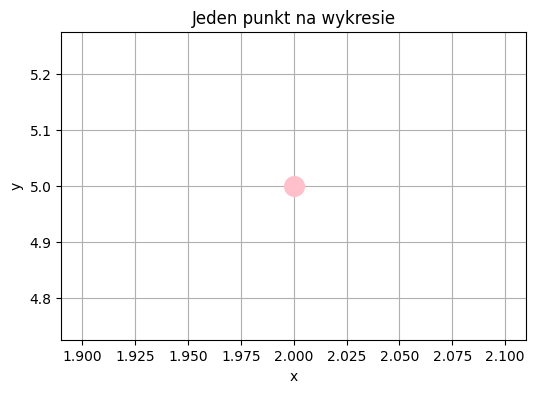

In [ ]:
# plt.scatter rysuje pojedyncze punkty, nie łączy ich linią
x_punkt = [2]
y_punkt = [5]

plt.figure(figsize=(6, 4))
plt.scatter(x_punkt, y_punkt,
            color='pink',    # kolor punktu
            s=200,          # rozmiar punktu (domyślnie 36))
            zorder = 2)     # zorder decyduje co jest "na wierzchu"
plt.xlabel('x')
plt.ylabel('y')
plt.title('Jeden punkt na wykresie')
plt.grid(True) #alpha=0.4 wywalamy żeby było bardziej widoczne
plt.show()

### 1.3 Punkty połączone prostą

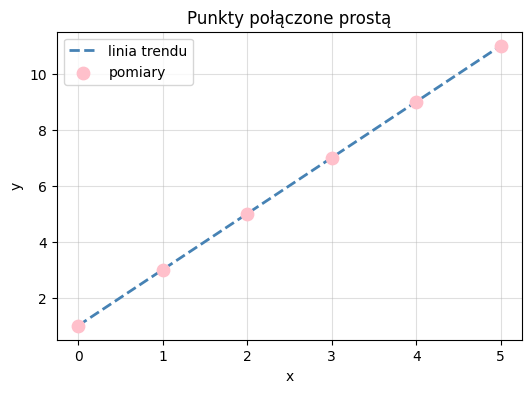

In [ ]:
# plt.plot i plt.scatter można łączyć na jednym wykresie
# Dwa wywołania przed plt.show() rysują na tej samej figurze

x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))

# linia
plt.plot(x, y,
         color='steelblue',
         linewidth=2,
         linestyle='--',    # '--' przerywana, '-' ciągła, ':' kropkowana
         label='linia trendu')

# punkty na tej samej figurze
plt.scatter(x, y,
            color='pink',
            s=80,
            zorder=5,
            label='pomiary')
# zorder to że ma być na prostej ????
plt.xlabel('x')
plt.ylabel('y')
plt.title('Punkty połączone prostą')
plt.legend()               # legenda — bierze etykiety z label=
plt.grid(True, alpha=0.4)
plt.show()

### Zadanie 1

Narysuj na jednym wykresie dwie proste:
- `y1 = x` (kolor zielony, linia ciągła)
- `y2 = x**2` (kolor pomarańczowy, linia przerywana `'--'`)

Zakres x: `[0, 1, 2, 3, 4]`  
Dodaj tytuł, etykiety osi i legendę.

> 💡 Dwa razy `plt.plot(...)` przed `plt.show()` rysuje obie linie na jednym wykresie.

In [ ]:
x = [0, 1, 2, 3, 4]
y2 = []
for element in x:
  y2.append(element ** 2)
print(y2)

[0, 1, 4, 9, 16]


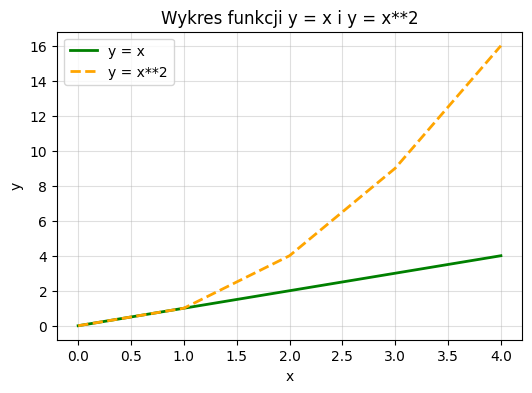

In [ ]:
x = [0, 1, 2, 3, 4]
y1 = x
y2 = [0, 1, 4, 9, 16]

plt.figure(figsize=(6, 4)) # kartka papieru zawsze ma być piwrwsza bo inaczej bummmm
plt.plot(x, y1, color = 'green', linewidth=2,
         linestyle='-', label='y = x')    # '--' przerywana, '-' ciągła, ':' kropkowana
plt.plot(x, y2, color = 'orange', linewidth = 2, linestyle = '--', label='y = x**2' )
plt.title('Wykres funkcji y = x i y = x**2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

---
## 2. Wgrywanie danych i eksploracja


### 2.1 Wczytanie danych

In [ ]:
# Zbiór Palmer Penguins — wbudowany w Seaborn, nie trzeba nic pobierać
df = sns.load_dataset('penguins')

# Jak wyświetlić pierwsze 7 wierszy?
df.head(7)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female


### 2.2 Podstawowe informacje o zbiorze

In [ ]:
# Wyświetlamy wymiar danych: (wiersze, kolumny)
print('Wymiar:', df.shape)
print()

# Wyświetlamy typy kolumn i liczba braków
print('Typy kolumn i braki:')
print(df.info())

Wymiar: (344, 7)

Typy kolumn i braki:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [ ]:
# Czy są braki w danych?
print('Liczba braków w każdej kolumnie:')
print(df.isna().sum())
print()
print(f'Wierszy z co najmniej jednym brakiem: {df.isnull().any(axis=1).sum()}')

Liczba braków w każdej kolumnie:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Wierszy z co najmniej jednym brakiem: 11


In [ ]:
# Podstawowe statystyki opisowe dla kolumn liczbowych
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


In [ ]:
# Ile pingwinów każdego gatunku?
print('Liczba pingwinów wg gatunku:')
# kolumna species
print(df['species'].value_counts())
print()
# kolumna island
print('Liczba pingwinów wg wyspy:')
print(df['island'].value_counts())

Liczba pingwinów wg gatunku:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Liczba pingwinów wg wyspy:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [ ]:
# Usuwamy wiersze z brakami — reszta zajęć na czystych danych
df = df.dropna().reset_index(drop=True)
print(f'Wierszy po usunięciu braków: {len(df)}')

# Słownik kolorów — używamy go przez cały notatnik dla spójności
KOLORY = {'Adelie': '#F4A026', 'Gentoo': '#1B8A7A', 'Chinstrap': '#9B4EC8'}
df

Wierszy po usunięciu braków: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


###  Zadanie 2

1. Ile jest unikalnych wartości w kolumnie `island`?
2. Jaka jest średnia masa ciała (`body_mass_g`) dla każdego gatunku?  
3. Ile pingwinów to samce, ile samice?

In [ ]:
# Twoje rozwiązanie:

# 1. Unikalne wyspy
i = df["island"].nunique()
# 2. Średnia masa wg gatunku
m = df.groupby("species")["body_mass_g"].mean()
# 3. Podział na płeć
s = df.sex.value_counts()
print( i )
print (m)
print( s)

3
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64
sex
Male      168
Female    165
Name: count, dtype: int64


---
## 3. Pie chart — rozkład klas


Pie chart przydaje się gdy chcemy pokazać **udziały procentowe** kategorii.  
Używamy go gdy mamy 2–5 kategorii — przy większej liczbie trudno odczytać wartości.

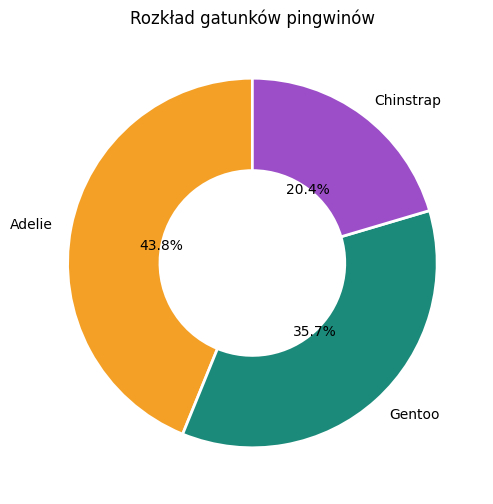

In [ ]:
# Zliczamy pingwiny wg gatunku
gatunki = df['species'].value_counts()
#explode = (0,0,0.1) to podnosi częśc z wykresu do góry
plt.figure(figsize=(6, 6))
plt.pie(
    gatunki.values,
    labels=gatunki.index,
    colors=list(KOLORY.values()),
    autopct = '%1.1f%%',
    startangle= 90, #dzieki temu czytelne bardziej
    #explode=explode
    pctdistance=0.5,
    wedgeprops={'width' : 0.5,
        'edgecolor': 'white',
                'linewidth' : 2}
)
plt.title('Rozkład gatunków pingwinów', fontsize = 12)
plt.show()

###  Zadanie 3

Narysuj pie chart pokazujący **rozkład wysp** (kolumna `island`), nie gatunków.  
Użyj dowolnych kolorów. Dodaj tytuł.

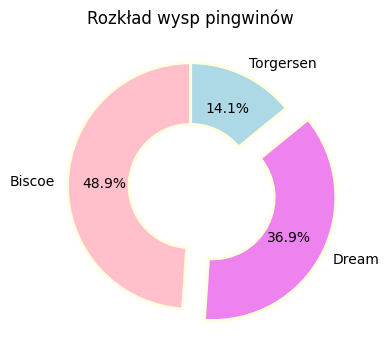

In [ ]:
# Twoje rozwiązanie:
kolorki = ['pink', 'violet', 'lightblue']
explode = (0,0.2,0)
wyspy = df['island'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(
    wyspy.values,
    labels=wyspy.index,
    colors=kolorki,
    autopct = '%1.1f%%',
    startangle= 90,
    explode=explode,
    pctdistance=0.7,
    wedgeprops={'width' : 0.5,
        'edgecolor': 'lightyellow',
                'linewidth' : 2}
)

plt.title('Rozkład wysp pingwinów', fontsize = 12)
plt.show()

---
## 4. Histogram — rozkład jednej zmiennej


Histogram dzieli zakres wartości na przedziały (`bins`) i liczy ile obserwacji wpada do każdego.  
Używamy go do sprawdzenia **kształtu rozkładu** — czy jest normalny, skośny, wielomodalny.

### 4.1 Podstawowy histogram

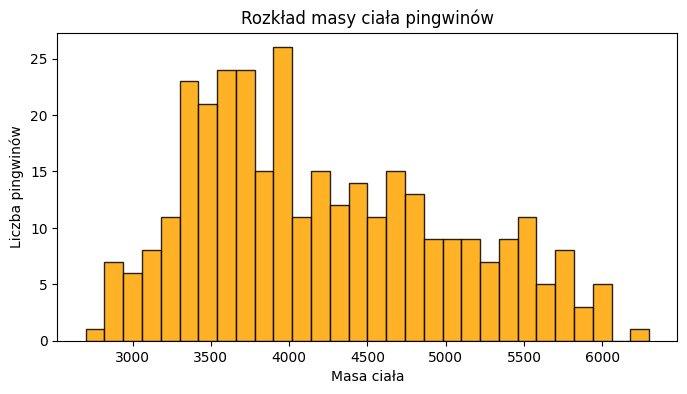

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['body_mass_g'], bins =30, color = 'orange', alpha = 0.85, edgecolor = 'black')
plt.xlabel('Masa ciała')
plt.ylabel('Liczba pingwinów')
plt.title('Rozkład masy ciała pingwinów')
plt.show()

### 4.2 axvline — linie dla mediany i średniej

Kiedy chcemy zaznaczyć na histogramie konkretną wartość (próg, statystykę) — używamy `plt.axvline()`.

In [ ]:
srednia = df['body_mass_g'].mean()
mediana = df['body_mass_g'].median()
print(f'Srednia: {srednia:.0f} g')
print(f'Mediana: {mediana:.0f} g')

Srednia: 4207 g
Mediana: 4050 g


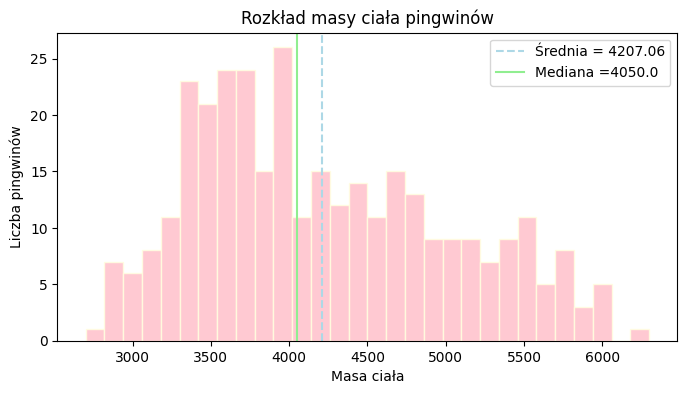

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['body_mass_g'], bins =30, color = 'pink', alpha = 0.85, edgecolor = 'lightyellow')
plt.axvline(x= srednia, color = 'lightblue', linestyle = '--', label = f'Średnia = {srednia.round(2)}')
plt.axvline(x= mediana, color = 'lightgreen', linestyle = '-', label = f'Mediana ={mediana}')
plt.legend()
plt.xlabel('Masa ciała')
plt.ylabel('Liczba pingwinów')
plt.title('Rozkład masy ciała pingwinów')
plt.show()

### 4.3 Histogram z podziałem na gatunki

Żeby zobaczyć rozkłady osobno dla każdego gatunku — rysujemy kilka histogramów na jednym wykresie.  
Kluczowe: `alpha` (przezroczystość) żeby się nie zasłaniały.

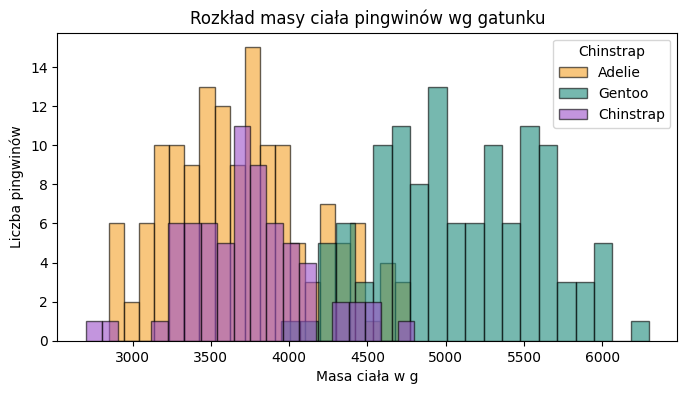

In [ ]:
plt.figure(figsize=(8, 4))
#KOLORY = {'Adelia' : 'hotpink', 'Gento' : 'azure', 'Chinstrap' : 'plum'}
for gatunek, kolor in KOLORY.items():
  dane = df[df['species']==gatunek]['body_mass_g']
  plt.hist(dane, bins =20, alpha=0.6, color=kolor, edgecolor = 'black' , label = gatunek)
plt.xlabel('Masa ciała w g')
plt.ylabel('Liczba pingwinów')
plt.title('Rozkład masy ciała pingwinów wg gatunku')
plt.legend(title = gatunek)
plt.show()

###  Zadanie 4

1. Narysuj histogram **długości dzioba** (`bill_length_mm`) dla całego zbioru.  
   Dodaj linie dla mediany i średniej.

2. Narysuj drugi histogram tej samej cechy, ale z podziałem na gatunki (pętla + `alpha=0.6`).

3. **Pytanie:** Histogram z punktu 1 ma dwa garby. Dlaczego? Co wyjaśnia histogram z punktu 2?

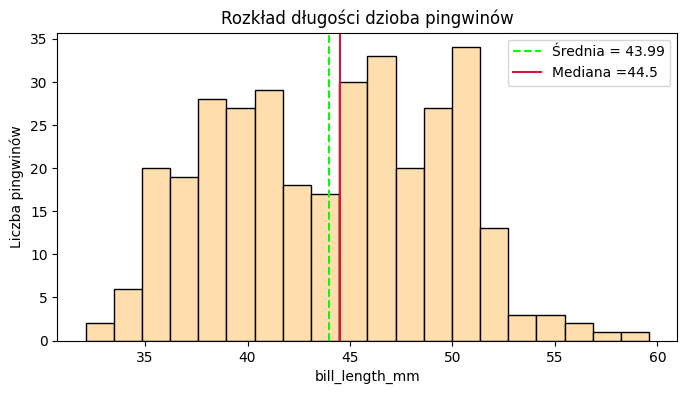

In [ ]:
# Twoje rozwiązanie — wykres 1:
srednia = df['bill_length_mm'].mean()
mediana = df['bill_length_mm'].median()
plt.figure(figsize=(8, 4))
plt.hist(df['bill_length_mm'], bins = 20, color = 'navajowhite' , edgecolor = 'black')
plt.axvline(x= srednia, color = 'lime', linestyle = '--', label = f'Średnia = {srednia.round(2)}')
plt.axvline(x= mediana, color = 'crimson', linestyle = '-', label = f'Mediana ={mediana}')
plt.xlabel('bill_length_mm')
plt.ylabel('Liczba pingwinów')
plt.title('Rozkład długości dzioba pingwinów')
plt.legend()
plt.show()

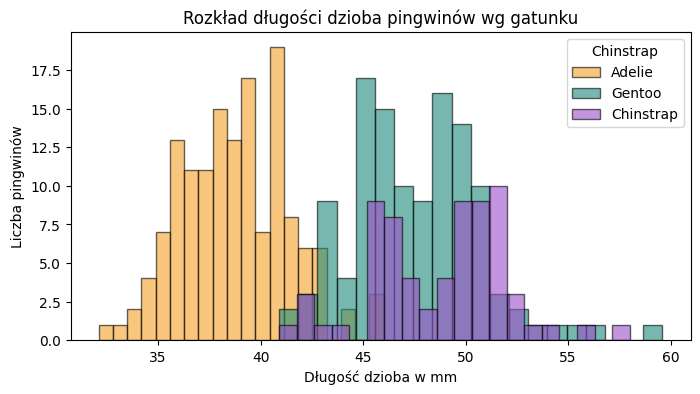

In [ ]:
# Twoje rozwiązanie — wykres 2:
plt.figure(figsize=(8, 4))
#colors = {'Adelia' : 'lightblue', 'Gento' : 'lightpink', 'Chinstrap' : 'plum'}
for gatunek, color in KOLORY.items():
  dane = df[df['species']==gatunek]['bill_length_mm']
  plt.hist(dane, bins =20, alpha=0.6, color=color, edgecolor = 'black' , label = gatunek)
plt.xlabel('Długość dzioba w mm')
plt.ylabel('Liczba pingwinów')
plt.title('Rozkład długości dzioba pingwinów wg gatunku')
plt.legend(title = gatunek)
plt.show()


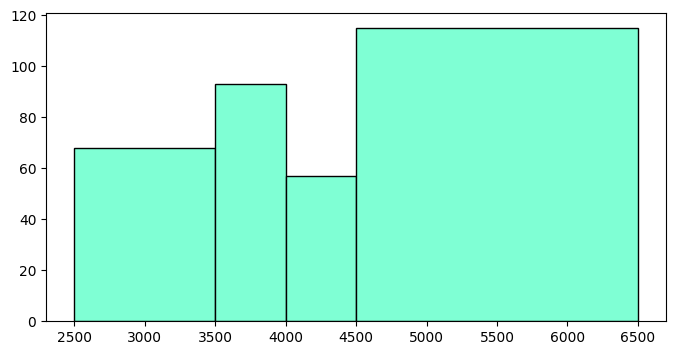

In [ ]:
bins_masa=[2500, 3500, 4000, 4500, 6500]
plt.figure(figsize=(8, 4))
plt.hist(df['body_mass_g'], bins = bins_masa, color = 'aquamarine' , edgecolor = 'black')
plt.show()

---
## 5. Boxplot i Violinplot — dane odstające i rozkład


### Jak czytać boxplot?

```
         |--wąs--|  [  Q1 | mediana | Q3  ]  |--wąs--|  o (outlier)
```

- **Pudełko** = zakres między Q1 (25%) a Q3 (75%) — tu mieszka środkowe 50% danych
- **Linia środkowa** = mediana
- **Wąsy** = maksymalnie 1.5 × IQR poza pudełkiem
- **Punkty poza wąsami** = potencjalne wartości odstające (outliery)

/tmp/ipykernel_242/2297365817.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)


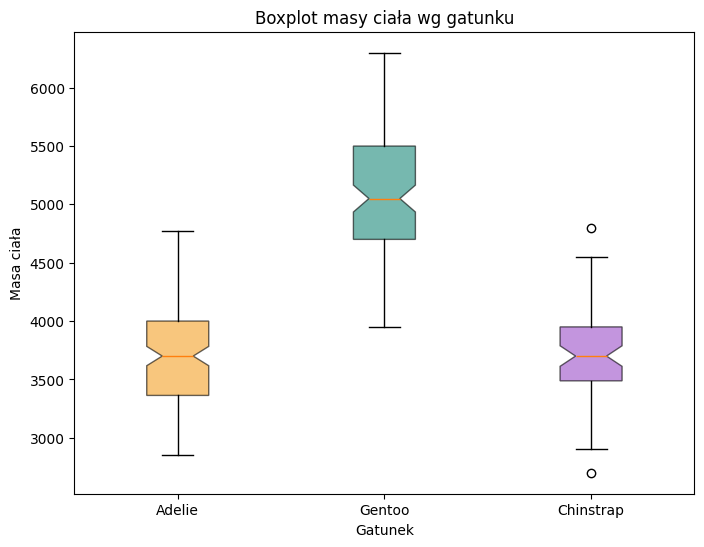

In [ ]:
grupy = [df[df['species'] == g]['body_mass_g'] for g in KOLORY.keys()]
etykiety = list(KOLORY.keys())
plt.figure(figsize=(8, 6))
bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)
for patch, kolor in zip(bp['boxes'], KOLORY.values()):
    patch.set_facecolor(kolor)
    patch.set_alpha(0.6)
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Boxplot masy ciała wg gatunku')
plt.show()

### 5.1 Podstawowy boxplot

In [ ]:
COLORY = {
    'Adelie': '#FFB7CE',    # Ładny, miękki pastelowy róż
    'Gentoo': '#AEC6CF',    # Spokojny pastelowy błękit
    'Chinstrap': '#C3B1E1'  # Delikatny, lawendowy fiolet
}

/tmp/ipykernel_242/3183038034.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)


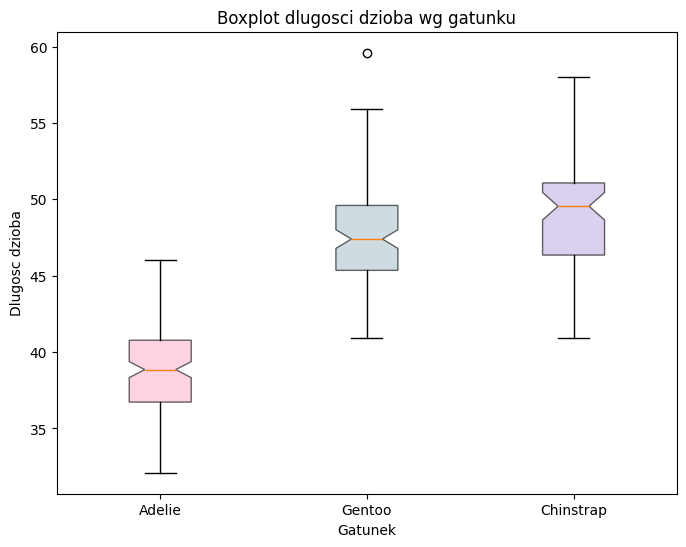

In [ ]:
grupy = [df[df['species'] == g]['bill_length_mm'] for g in COLORY.keys()]
etykiety = list(COLORY.keys())
plt.figure(figsize=(8, 6))
bp = plt.boxplot(grupy, labels=etykiety, patch_artist=True, notch=True)
for patch, kolor in zip(bp['boxes'], COLORY.values()):
    patch.set_facecolor(kolor)
    patch.set_alpha(0.6)
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.title('Boxplot dlugosci dzioba wg gatunku')
plt.show()

### 5.2 Boxplot z podziałem na płeć

Chcemy zobaczyć czy samce i samice różnią się masą ciała w obrębie każdego gatunku.  
Tu z pomocą przychodzi Seaborn — jedną linią robimy to co w Matplotlib wymagałoby wielu pętli.

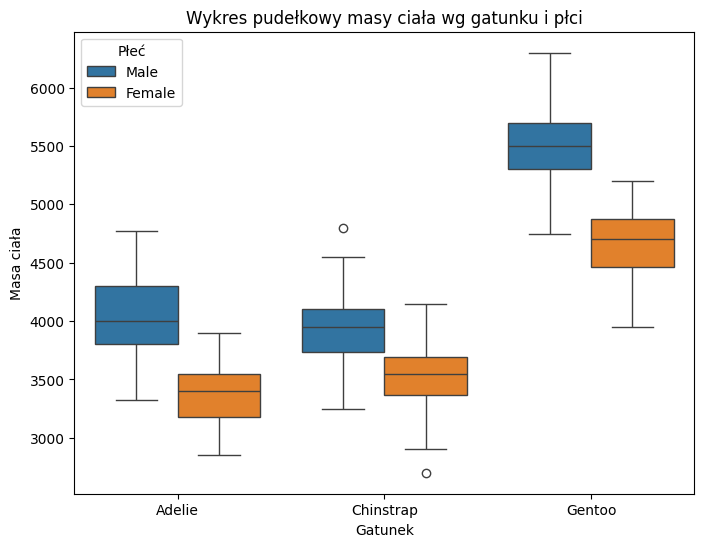

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex')
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Wykres pudełkowy masy ciała wg gatunku i płci')
plt.legend(title='Płeć', loc = 'upper left')
plt.show()

### 5.3 Violinplot

Violinplot łączy boxplot z rozkładem gęstości.  
Szerokość "skrzypiec" = gęstość prawdopodobieństwa w danym miejscu — im szerzej, tym więcej obserwacji.

/tmp/ipykernel_242/889122151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='body_mass_g', palette=list(COLORY.values()))


Text(0.5, 1.0, 'Wykres wiolinowy masy ciała wg gatunku')

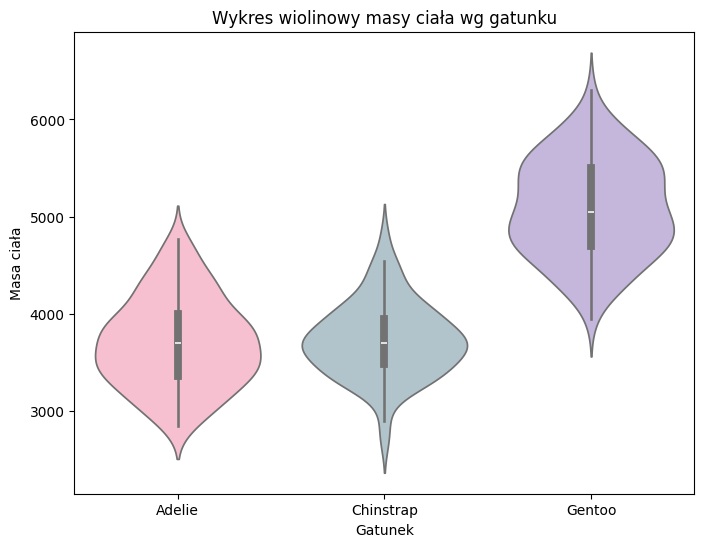

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='species', y='body_mass_g', palette=list(COLORY.values()))
plt.xlabel('Gatunek')
plt.ylabel('Masa ciała')
plt.title('Wykres wiolinowy masy ciała wg gatunku')

### Zadanie 5

1. Narysuj boxplot dla **długości dzioba** (`bill_length_mm`) — podział wg gatunku.  
   Pokoloruj pudełka kolorami z `KOLORY`.

2. Narysuj violinplot dla **głębokości dzioba** (`bill_depth_mm`) z podziałem na płeć (`hue='sex'`).

3. **Pytanie:** Który gatunek ma największy rozrzut masy ciała (najszersze pudełko)?

/tmp/ipykernel_242/1573485200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='bill_length_mm', palette=[COLORY[gatunek] for gatunek in df['species'].unique()])
/tmp/ipykernel_242/1573485200.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Płeć', loc = 'upper left')


Text(0.5, 1.0, 'Wykres pudełkowy dlugosci dzioba wg gatunku')

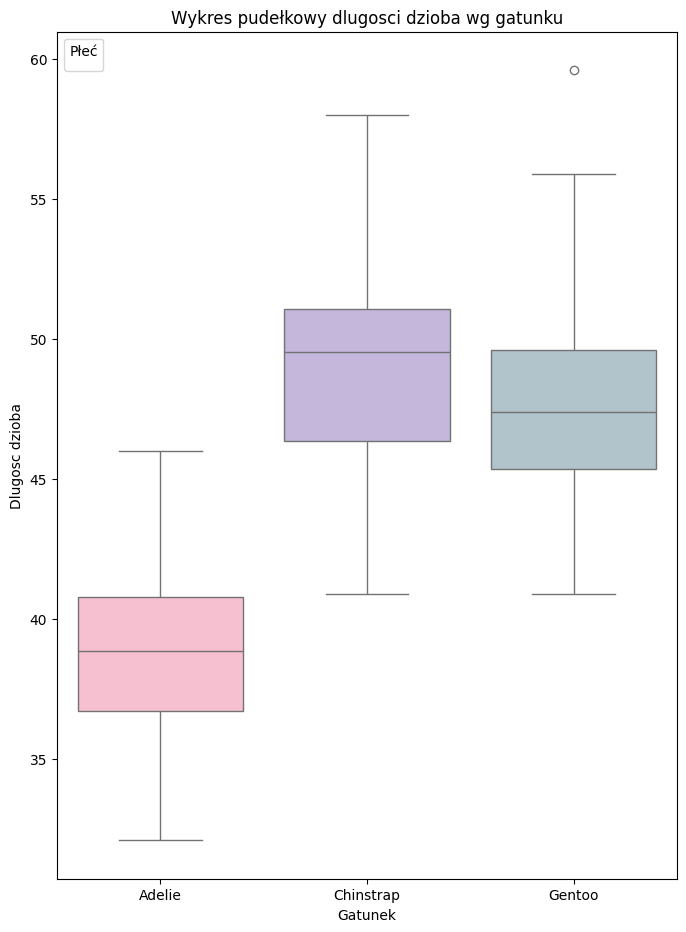

In [ ]:
# Twoje rozwiązanie — boxplot:
plt.figure(figsize=(8,11))
sns.boxplot(data=df, x='species', y='bill_length_mm', palette=[COLORY[gatunek] for gatunek in df['species'].unique()])
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.legend(title='Płeć', loc = 'upper left')
plt.title('Wykres pudełkowy dlugosci dzioba wg gatunku')

/tmp/ipykernel_242/2414585195.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df, x='species', y='bill_length_mm', hue ='sex', split=True, palette=list(COLORY.values()))


Text(0.5, 1.0, 'Wykres wiolinowy dlugosci dzioba wg gatunku i płci')

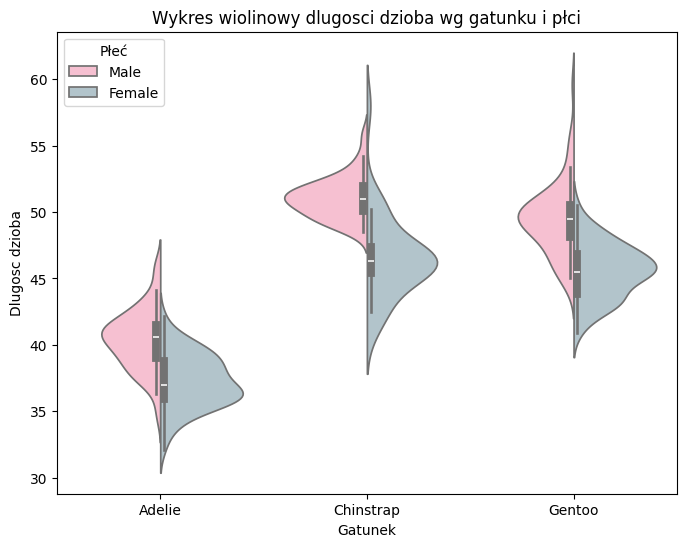

In [ ]:
# Twoje rozwiązanie — violinplot:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='species', y='bill_length_mm', hue ='sex', split=True, palette=list(COLORY.values()))
plt.xlabel('Gatunek')
plt.ylabel('Dlugosc dzioba')
plt.legend(title='Płeć', loc = 'upper left')
plt.title('Wykres wiolinowy dlugosci dzioba wg gatunku i płci')



---
## 6. Scatter plot i adnotacje


Scatter plot pokazuje zależność między dwiema zmiennymi ciągłymi. Każdy punkt = jeden pingwin.

### 6.1 Podstawowy scatter plot

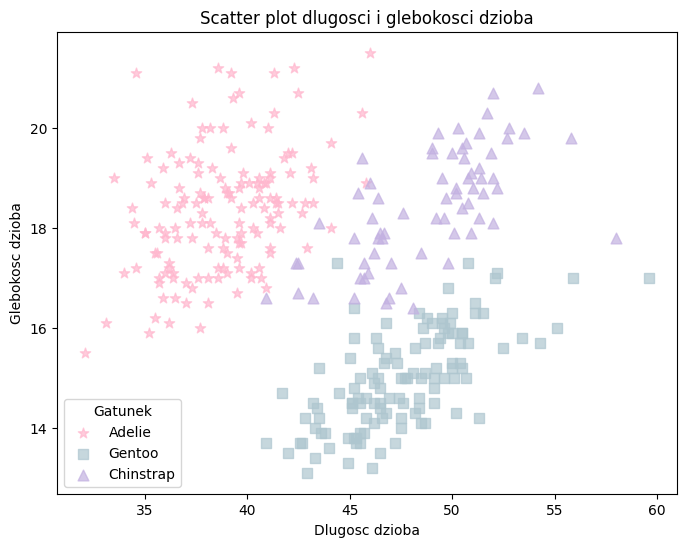

In [ ]:
plt.figure(figsize=(8, 6))
markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  pod = df[df['species']==gatunek]
  plt.scatter(pod['bill_length_mm'], pod['bill_depth_mm'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.7 )
plt.xlabel('Dlugosc dzioba')
plt.ylabel('Glebokosc dzioba')
plt.title('Scatter plot dlugosci i glebokosci dzioba')
plt.legend(title = 'Gatunek', loc = 'lower left')
plt.show()

### 6.2 Oznaczenie konkretnego punktu — plt.annotate

`plt.annotate` rysuje strzałkę wskazującą konkretny punkt danych.  
Przydatne gdy chcemy zwrócić uwagę na outlier, rekord, lub konkretnego osobnika.

In [ ]:
# Znajdźmy najcięższego pingwina
idx_max = df['body_mass_g'].idxmax()
x_max = df.loc[idx_max, 'flipper_length_mm']
y_max = df.loc[idx_max, 'body_mass_g']
g_max = df.loc[idx_max, 'species']
print(f"Najcięższy pingwin: {df['body_mass_g'][idx_max]}g, {g_max}")

Najcięższy pingwin: 6300.0g, Gentoo


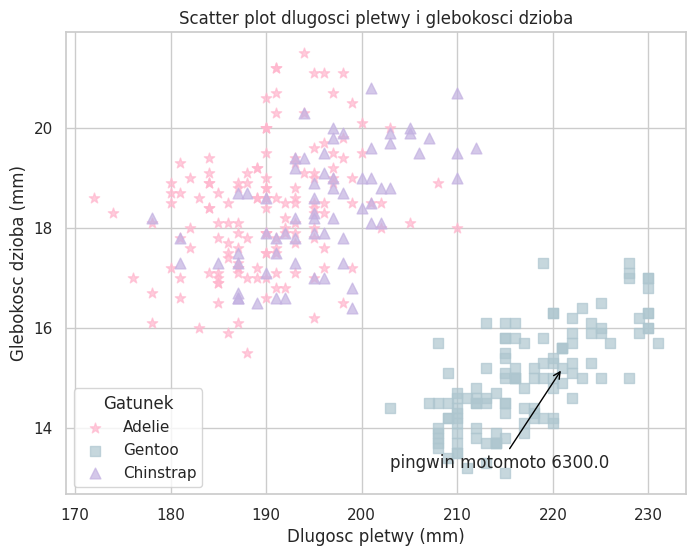

In [ ]:
plt.figure(figsize=(8, 6))
markery = {'Adelie' : '*', 'Gentoo' : 's', 'Chinstrap' : '^'}
for gatunek, kolor in COLORY.items():
  pod = df[df['species']==gatunek]
  plt.scatter(pod['flipper_length_mm'], pod['bill_depth_mm'], c=kolor, label=gatunek, s =60, marker =markery[gatunek], alpha = 0.7 )
plt.annotate(text = f"pingwin motomoto {df['body_mass_g'][idx_max]}", xy = (x_max, df.loc[idx_max, 'bill_depth_mm']), xytext = (x_max-18, df.loc[idx_max, 'bill_depth_mm']-2),
             arrowprops={'arrowstyle' : '->', 'color': 'black'})
plt.xlabel('Dlugosc pletwy (mm)')
plt.ylabel('Glebokosc dzioba (mm)')
plt.title('Scatter plot dlugosci pletwy i glebokosci dzioba')
plt.legend(title = 'Gatunek', loc = 'lower left')
plt.show()

### Zadanie 6

Na scatter plot `bill_length_mm` vs `bill_depth_mm`:
1. Narysuj wszystkie trzy gatunki różnymi kolorami z `KOLORY`
2. Znajdź pingwina z **najdłuższym dziobem**: `df['bill_length_mm'].idxmax()`
3. Oznacz go strzałką `plt.annotate` z tekstem zawierającym długość dzioba i gatunek

In [ ]:
# Twoje rozwiązanie:




---
## 7. Heatmapa korelacji


Korelacja mierzy siłę i kierunek zależności liniowej między dwiema zmiennymi:
- **+1** — pełna korelacja dodatnia (razem rosną)
- **0** — brak korelacji
- **-1** — pełna korelacja ujemna (jedna rośnie, druga maleje)

Macierz korelacji zestawia wszystkie pary zmiennych naraz.

In [ ]:
# Wybieramy tylko kolumny liczbowe i liczymy korelacje
cechy    = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
etykiety = ['Dl. dzioba', 'Gl. dzioba', 'Dl. pletwy', 'Masa ciala']



### Zadanie 7

1. Przeczytaj macierz korelacji: która para cech ma **największą korelację dodatnią**?
2. Czy jest para cech z **korelacją ujemną**? Jakie to cechy?
3. **Opcjonalne:** Policz korelacje osobno dla gatunku Gentoo:  
   `corr_gentoo = df[df['species']=='Gentoo'][cechy].corr()`  
   Czy korelacje są inne niż dla całego zbioru?

In [ ]:
# Twoje odpowiedzi:
# 1.
# 2.

# Opcjonalne — korelacje dla Gentoo:




---
## 8. Subplots — kilka wykresów obok siebie


`plt.subplots(wiersze, kolumny)` tworzy siatkę wykresów na jednej figurze.  
Zwraca dwa obiekty: `fig` (cała figura) i `axes` (tablica osi).

```python
fig, axes = plt.subplots(1, 2)   # 1 wiersz, 2 kolumny
#  axes[0] — lewy wykres
#  axes[1] — prawy wykres
```

Ważna różnica: zamiast `plt.xlabel()` używamy `axes[i].set_xlabel()`

### 8.1 Trzy histogramy poziomo (1 wiersz, 3 kolumny)

### 8.2 Trzy histogramy pionowo (3 wiersze, 1 kolumna)

Zmieniamy tylko `subplots(3, 1)` i `figsize` — reszta kodu identyczna.

### 8.3 Mieszany układ — wykres słupkowy obok scatter plot

Siatka 1×2 z dwoma różnymi typami wykresów.

###  Zadanie 8

Utwórz siatkę `plt.subplots(2, 2)` z czterema wykresami:
- `axes[0, 0]` — histogram masy ciała (z podziałem na gatunki)
- `axes[0, 1]` — boxplot długości płetwy (wg gatunku, użyj `sns.boxplot(..., ax=axes[0,1])`)
- `axes[1, 0]` — scatter długość dzioba vs głębokość dzioba
- `axes[1, 1]` — heatmapa korelacji (`sns.heatmap(..., ax=axes[1,1])`)

> 💡 Dla siatki 2×2: `axes[wiersz, kolumna]` np. `axes[0, 0]`, `axes[1, 1]`

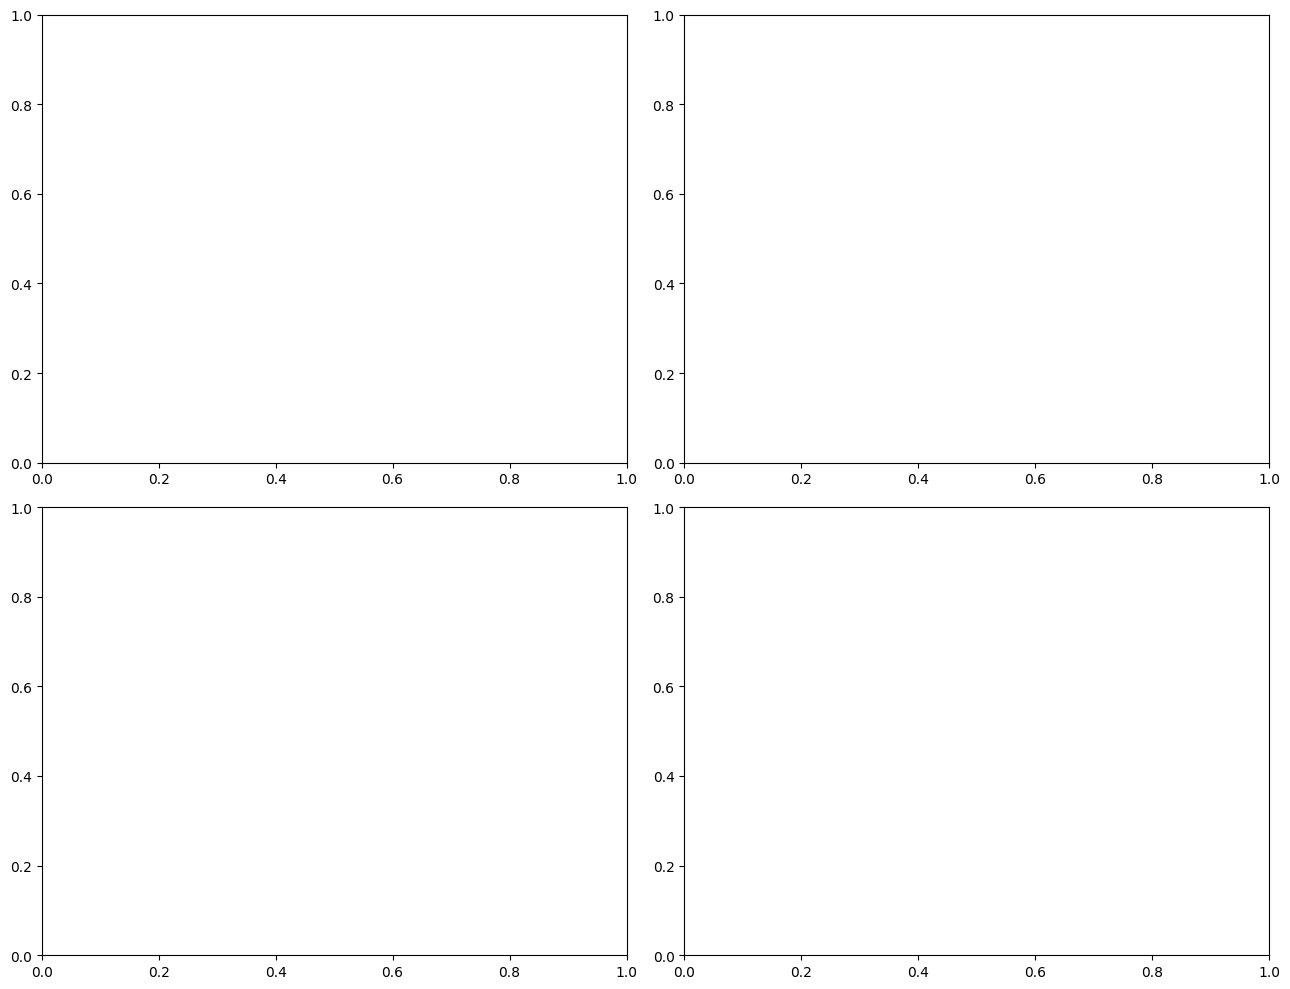

In [ ]:
# Twoje rozwiązanie:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# axes[0, 0] — histogram masy ciała


# axes[0, 1] — boxplot dlugosci pletwy
# sns.boxplot(data=df, x='species', y='flipper_length_mm', ..., ax=axes[0, 1])


# axes[1, 0] — scatter ksztaltu dzioba


# axes[1, 1] — heatmapa korelacji
# sns.heatmap(corr, ..., ax=axes[1, 1])


plt.tight_layout()
plt.show()

---
## 9. Seaborn — te same wykresy, mniej kodu


Seaborn to nakładka na Matplotlib. Rozumie ramki danych pandas bezpośrednio  
i obsługuje grupowanie jednym parametrem `hue=`.

**Kluczowa różnica:**
```python
# Matplotlib — pętla, ręczne filtrowanie
for gatunek, kolor in KOLORY.items():
    dane = df[df['species'] == gatunek]['body_mass_g']
    plt.hist(dane, alpha=0.6, color=kolor, label=gatunek)
plt.legend()

# Seaborn — jedna linia robi to samo
sns.histplot(data=df, x='body_mass_g', hue='species')
```

Matplotlib zostaje "pod spodem" — `plt.title()`, `plt.xlabel()`, `plt.savefig()` działają tak samo.

In [ ]:
sns.set_theme(style='whitegrid')   # globalny styl — działa na wszystkie kolejne wykresy
print('Seaborn gotowy!')

Seaborn gotowy!


### 9.1 sns.histplot z KDE

### 9.2 sns.boxplot z hue — podział na płeć jednym parametrem

### 9.3 sns.scatterplot i sns.heatmap

### 9.4 sns.pairplot — wszystkie pary naraz

`sns.pairplot` rysuje macierz wykresów: każda cecha vs każda inna cecha.  
Na przekątnej — rozkłady (histogram lub KDE). Poza przekątną — scatter plot.

###  Zadanie 9

1. Narysuj `sns.violinplot` dla `body_mass_g` z podziałem na gatunki i płeć (`hue='sex'`).  
   Porównaj z boxplotem z Zadania 5 — co violinplot mówi więcej?

2. Użyj `sns.pairplot` ale z `diag_kind='hist'` zamiast `'kde'`. Czy coś się zmieniło?

3. Utwórz subplots `1×3` z trzema wykresami Seaborn obok siebie:
   - violinplot długości dzioba
   - boxplot masy ciała
   - scatterplot długość vs głębokość dzioba

In [ ]:
# Twoje rozwiązanie — zadanie 1:




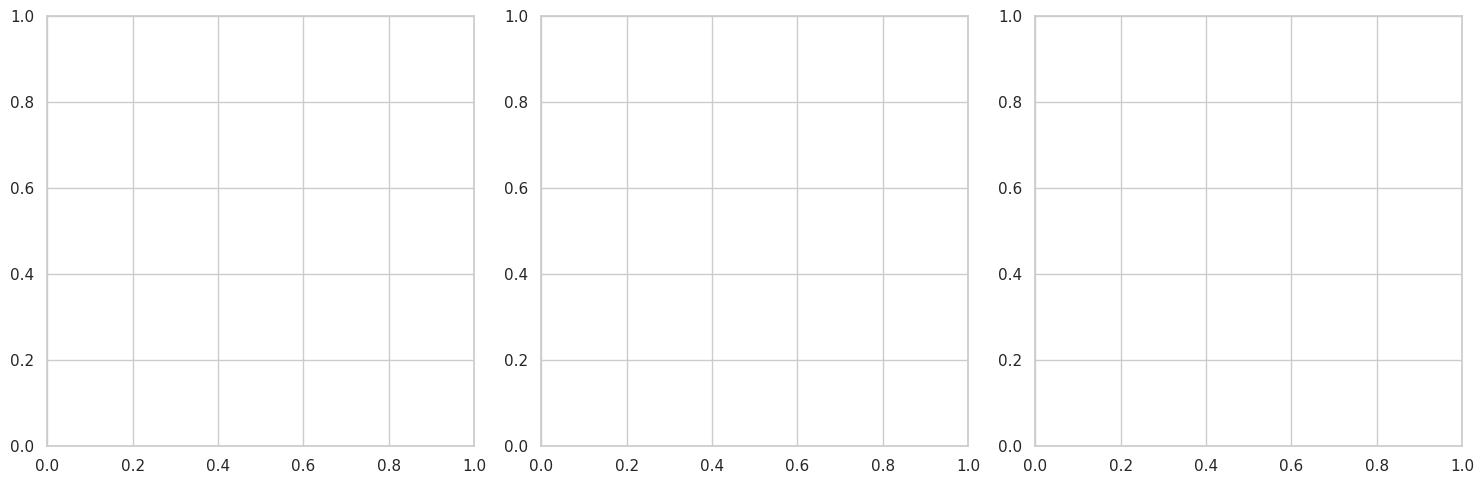

In [ ]:
# Twoje rozwiązanie — zadanie 3:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0] — violinplot


# axes[1] — boxplot


# axes[2] — scatterplot


plt.tight_layout()
plt.show()

---
## Podsumowanie

### Matplotlib — kiedy używać?
- Pełna kontrola nad każdym elementem wykresu
- Własne pętle, niestandardowe układy
- `plt.annotate` — wskazywanie konkretnych punktów

### Seaborn — kiedy używać?
- Szybka eksploracja danych z grupowaniem (`hue=`)
- `pairplot` — bez odpowiednika w Matplotlib

### Mapa funkcji

| Zadanie | Matplotlib | Seaborn |
|---------|------------|---------|
| Linia | `plt.plot()` | — |
| Punkty | `plt.scatter()` | `sns.scatterplot()` |
| Histogram | `plt.hist()` | `sns.histplot()` |
| Boxplot | `plt.boxplot()` | `sns.boxplot()` |
| Violinplot | — | `sns.violinplot()` |
| Heatmapa | `plt.imshow()` | `sns.heatmap()` |
| Linia pionowa | `plt.axvline()` | — |
| Wiele wykresów | `plt.subplots()` | `ax=` w sns |
| Wszystkie pary | — | `sns.pairplot()` |
| Grupowanie danych | ręczna pętla | `hue='kolumna'` |

### Cechy dobrego wykresu
- Tytuł, etykiety obu osi **z jednostkami**, legenda
- `alpha` gdy dane się nakładają
- `plt.tight_layout()` zapobiega nakładaniu etykiet
- Spójna paleta kolorów przez cały projekt